# Step 2a — Disparity filter, department-restricted (variant)

A variant of `02a_filter_disparity.ipynb`, **not a replacement**: the base notebook and its outputs stay exactly as they are. Everything here is written under `disparity_dept` names.

The base disparity run left almost every anchor with a degree `k` near the full catalogue size (28,144–49,686; median 49,610). At that scale the disparity filter's null model degenerates — a "fair share" so tiny that only a single overwhelmingly dominant candidate can ever look significant — so most anchors either fell back to the flat 0.70 baseline or produced a threshold so extreme it matched nothing the walk actually touched.

This variant restricts each anchor's local network to **same-department** candidates before any disparity maths runs (not same-aisle: aisle is too fine and would sever genuine cross-aisle substitute pairs like almond milk vs dairy milk; department is coarser and should still shrink `k` substantially, roughly 21 departments across ~49,688 products versus 134 aisles). The restriction is enforced in **both** places — the `theta` computation in §4 and the sentence filter in §5 — so no cross-department candidate can slip through on raw similarity alone. `ALPHA_LEVEL` is left at the base run's 0.05 so the only thing that changed is `k`.

**Inputs** (in `outputs/`)
- `walk_raw_paths.jsonl` — raw walks (`anchor_id`, `raw_path`, `raw_sims`, `hops_taken`)
- `walk_config.json` — the walk run this filter is built on (for traceability)
- `product_basket_freq.json` — per-product basket counts for the popularity check
- `embeddings.npy`, `product_id_to_index.json`, `products_text.csv` — Step 1 vectors, id map, and metadata (the last supplies the `department` column this variant needs)
- `filters/disparity/alpha_0.05/thresholds.json` — base run, read **only** for the degree-`k` comparison

**Outputs** (to `outputs/`)
- `filters/disparity_dept/alpha_0.05/thresholds.json` — per-anchor `{theta, k, n_significant, fallback}`
- `filters/disparity_dept/alpha_0.05/walk_sentences.jsonl` — one kept sentence per line
- `filters/disparity_dept/alpha_0.05/filter_config.json` — method, alpha_level, restriction, counts, timestamps
- `filters/disparity_dept/alpha_0.05/walk_sentences_readable.txt` — human-readable kept sentences

No extra dependency — plain numpy covers this method entirely.

## 1. Imports and paths

Paths are resolved relative to the project root so the notebook works regardless of where Jupyter is launched from.

In [1]:
import json
import time
import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
STEP1_DIR = OUT_DIR / "step1"

print("Data dir:   ", DATA_DIR)
print("Outputs dir:", OUT_DIR)

Data dir:    /Users/linnhtet/Developer/bachelor-thesis/data
Outputs dir: /Users/linnhtet/Developer/bachelor-thesis/outputs


## 2. Parameters

Same knobs as the base disparity notebook. `ALPHA_LEVEL` is deliberately left unchanged so this experiment isolates the department restriction alone — any change in outcomes is attributable to `k` shrinking, not to also moving the significance level. There is no single `theta`: each anchor gets its own in §4, falling back to the constant baseline when nothing is significant.

In [2]:
METHOD_NAME = "disparity_dept"
VALUE_LABEL = "alpha_0.05"
FILTER_DIR = OUT_DIR / "filters" / METHOD_NAME / VALUE_LABEL
FILTER_DIR.mkdir(parents=True, exist_ok=True)

# ---- Adaptive threshold rule ----
ALPHA_LEVEL = 0.05   # UNCHANGED from the base disparity run, on purpose: this variant
                     # isolates the department restriction, so any change in outcomes is
                     # attributable to k shrinking, not to also moving the significance level.

CONSTANT_THETA_BASELINE = 0.70   # comparison baseline; ALSO the fallback theta
                                 # when no candidate is significant (see §4).

min_sentence_length = 2    # discard sentences shorter than this (same rule as siblings)

# Stress-test anchors — must match those 02_semantic_walk.ipynb always walked.
STRESS_TEST_IDS = {
    4210:  "Whole Milk",
    6347:  "Unsweetened Almond Milk",
    651:   "Organic Salted Butter",
    16268: "Vegan Butter",
    6104:  "Whole Milk Plain Yogurt",
    920:   "Coconut Yogurt",
}

## 3. Load the raw walks and supporting artifacts

Everything this notebook needs was produced upstream: the raw walks and walk config from `02_semantic_walk.ipynb`, the per-product basket counts (so the popularity check never rebuilds the basket graph), and Step 1's embeddings + id map — used **both** to compute the per-anchor thresholds (§4) and for the rank novelty test.

This variant also builds a department lookup: `id_to_dept` (product_id -> department, the same way `id_to_name` is built from `products_text.csv`) and `dept_by_row`, a per-embedding-row department array aligned **explicitly** to `pid_to_idx`'s index scheme (not assumed positional), so the department mask in §4 is a fast vectorised comparison rather than a lookup rebuilt per anchor.

In [3]:
# Raw walks from the walk notebook (one JSON object per line).
raw_walks = []
with open(OUT_DIR / "walk_raw_paths.jsonl") as f:
    for line in f:
        raw_walks.append(json.loads(line))

# The walk run this filter is built on — its timestamp is recorded for traceability.
with open(OUT_DIR / "walk_config.json") as f:
    walk_config = json.load(f)

# Per-product sampled-basket counts (for the background popularity check).
with open(OUT_DIR / "product_basket_freq.json") as f:
    freq = json.load(f)
total_baskets = freq["total_baskets"]
product_basket_count = {int(pid): c for pid, c in freq["product_basket_count"].items()}

# Step 1 artifacts: embeddings (unit-normalised) + id map for both the threshold
# computation and the rank novelty test, and product metadata (names + departments).
embeddings = np.load(STEP1_DIR / "embeddings.npy").astype(np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / np.clip(norms, 1e-12, None)

with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(pid): row for pid, row in json.load(f).items()}

products_text = pd.read_csv(STEP1_DIR / "products_text.csv")
id_to_name = dict(zip(products_text["product_id"], products_text["product_name"]))
id_to_dept = dict(zip(products_text["product_id"], products_text["department"]))


def name(pid):
    return id_to_name.get(int(pid), f"?{pid}")


def names(ids):
    return [name(p) for p in ids]


# Department per embedding row, aligned to pid_to_idx's index scheme (built
# explicitly, not assuming products_text's row order matches the embedding rows).
dept_by_row = np.empty(len(embeddings), dtype=object)
for pid, idx in pid_to_idx.items():
    dept_by_row[idx] = id_to_dept.get(pid)

print(f"raw walks loaded      : {len(raw_walks):,}")
print(f"walk_config timestamp : {walk_config.get('timestamp')}")
print(f"basket counts         : {len(product_basket_count):,} products, "
      f"{total_baskets:,} total baskets")
print(f"embeddings            : {embeddings.shape}")
print(f"departments           : {len(set(dept_by_row)):,} distinct across "
      f"{len(dept_by_row):,} rows")

raw walks loaded      : 400,100
walk_config timestamp : 2026-08-08T14:06:21
basket counts         : 48,526 products, 1,000,000 total baskets
embeddings            : (49688, 384)
departments           : 21 distinct across 49,688 rows


## 4. Rank each anchor and compute its per-anchor theta — department-restricted

Same disparity-filter maths as the base notebook, but each anchor's local network is first restricted to **same-department candidates only**, before any of the `k`/`s`/`p_j`/`alpha_j` computation runs.

**Why department, not aisle.** The base run's degree `k` sat at 28,144–49,686 (median 49,610), essentially the whole catalogue for almost every anchor. That breaks the null model: with a "fair share" that microscopic, only a single runaway-dominant candidate can ever register as significant, which is not what real substitute sets look like (several comparably-good variants, not one winner). Restricting the network shrinks `k` toward the sizes the disparity filter was designed for. We restrict to **department** (~21 across ~49,688 products), not **aisle** (~134): aisle is too fine and would sever genuine cross-aisle pairs. Unsweetened Almond Milk's aisle is "soy lactose free" and Whole Milk's is "milk" — different aisles, but very likely the same department "dairy eggs". The verification step below confirms that directly against the data rather than assuming it.

**`anchor_sorted_sims` cannot be reused here.** The sibling version sorts the similarity values directly and throws away which product each value belonged to, but this variant needs that association to apply the department mask *before* sorting. So we write `anchor_dept_sorted_sims`, which masks to same-department (and drops the anchor itself) first, then sorts. Same "mask before sort" discipline as every filter notebook's self-exclusion, same reason: sorting can't undo who was allowed into consideration in the first place.

**`disparity_theta` is unchanged** from the base notebook — the `k < 2` guard, the `alpha` formula, the fallback logic are all identical. Only what gets fed into it changes: `k` is now "positive-similarity same-department candidates" rather than "positive-similarity candidates across the whole catalogue".

The restriction is enforced again in §5's filter step, not only here — otherwise a high-similarity cross-department candidate could still slip into a kept sentence, which is exactly the loophole this change closes.

In [4]:
def anchor_dept_sorted_sims(anchor_id):
    """Same-department-only similarity ranking, product_id association kept
    until the mask is applied, then discarded (only values feed the disparity
    math, same as the sibling function's return shape).

    Same "mask before sort" discipline as every other filter notebook's
    self-exclusion, same reason: what happens after sorting can't undo who
    was allowed into consideration in the first place.
    """
    a = pid_to_idx[anchor_id]
    anchor_dept = id_to_dept.get(anchor_id)
    sims = embeddings @ embeddings[a]

    mask = (dept_by_row == anchor_dept)
    mask[a] = False   # exclude the anchor itself too

    return np.sort(sims[mask])[::-1]   # descending, same-department candidates only


def disparity_theta(sorted_sims):
    """Disparity-filter threshold for one anchor's full descending ranking.

    Only positive similarities form the local network (this also drops
    anchor_sorted_sims' own -inf self-sentinel automatically, same effect as
    Kneedle's explicit filter, same underlying reason: it's not a real edge).
    k = degree, s = total strength, p_j = w_j / s, alpha_j = (1-p_j)**(k-1).
    Because p_j (and alpha_j) move monotonically with w_j for fixed k and s,
    significant candidates are always exactly the top-M by similarity for some
    M — no need to test out of rank order, no risk of a non-contiguous
    significant set. This is what lets the method reduce to a single per-anchor
    theta, same output shape as the other two, despite having nothing else in
    common with either mechanically.
    """
    positive = sorted_sims[sorted_sims > 0]
    k = len(positive)
    if k < 2:
        # (1-p)**(k-1) is undefined at k=0 or trivially 1.0 for any p at k=1 —
        # nothing could ever be significant either way. Fall back.
        return {"theta": CONSTANT_THETA_BASELINE, "k": k,
                "n_significant": 0, "fallback": True}

    s = float(positive.sum())
    p = positive / s
    alpha = (1.0 - p) ** (k - 1)
    n_significant = int((alpha < ALPHA_LEVEL).sum())   # monotonic -> a clean prefix count

    if n_significant == 0:
        return {"theta": CONSTANT_THETA_BASELINE, "k": k,
                "n_significant": 0, "fallback": True}

    theta = float(positive[n_significant - 1])   # similarity at the boundary
    return {"theta": theta, "k": k,
            "n_significant": n_significant, "fallback": False}


# Only anchors that were actually walked (not the full starting_products list).
walked_anchor_ids = sorted({int(w["anchor_id"]) for w in raw_walks})
print(f"walked anchors: {len(walked_anchor_ids):,}")

walked anchors: 20,005


### Verify the restriction preserves known-good pairs

This variant's whole safety rests on department being coarse enough to keep substitute pairs that live in different aisles. Print each stress-test anchor's department, then check a set of already-validated substitute pairs from prior runs: if any pair spans two departments, this restriction would silently exclude a pairing we already know is genuine, and the approach needs rethinking **before** the full run, not after.

In [5]:
# Department of each stress-test anchor.
print("Stress-test anchor departments:")
print("=" * 62)
for pid, nm in STRESS_TEST_IDS.items():
    print(f"  {nm:<30} ({pid}) -> {id_to_dept.get(pid)}")

# Resolve substitute names -> product_ids (names can repeat, so keep a list).
name_to_ids = {}
for pid_, nm_ in id_to_name.items():
    name_to_ids.setdefault(nm_, []).append(int(pid_))

# Already-validated substitute pairs from prior runs, given by name.
VALIDATED_PAIRS = [
    (4210,  "Organic Whole Milk"),
    (6347,  "Organic Unsweetened Almond Milk"),
    (6347,  "Unsweetened Almondmilk"),
    (651,   "Unsalted Butter"),
    (16268, "Vegan Egg"),
    (16268, "Unsalted Butter"),
]

print("\nKnown-good substitute pairs — same department?")
print("=" * 62)
any_warning = False
for anchor_id, sub_name in VALIDATED_PAIRS:
    anchor_dept = id_to_dept.get(anchor_id)
    sub_ids = name_to_ids.get(sub_name, [])
    if not sub_ids:
        print(f"  [ ? not found ] {name(anchor_id)} vs {sub_name!r}")
        any_warning = True
        continue
    for sid in sub_ids:
        sub_dept = id_to_dept.get(sid)
        same = (sub_dept == anchor_dept)
        tag = "same" if same else "DIFFERENT"
        print(f"  [{tag:>9}] {name(anchor_id)} ({anchor_dept})  vs  "
              f"{name(sid)} [{sid}] ({sub_dept})")
        if not same:
            any_warning = True

if any_warning:
    print("\n!!! WARNING: a known-good pair spans different departments (or a substitute "
          "was not found). This restriction would silently exclude a pairing we already "
          "know is genuine — rethink before trusting the full run.")
else:
    print("\nAll known-good pairs share a department: the restriction preserves them.")

Stress-test anchor departments:
  Whole Milk                     (4210) -> dairy eggs
  Unsweetened Almond Milk        (6347) -> dairy eggs
  Organic Salted Butter          (651) -> dairy eggs
  Vegan Butter                   (16268) -> dairy eggs
  Whole Milk Plain Yogurt        (6104) -> dairy eggs
  Coconut Yogurt                 (920) -> dairy eggs

Known-good substitute pairs — same department?
  [     same] Whole Milk (dairy eggs)  vs  Organic Whole Milk [27845] (dairy eggs)
  [     same] Unsweetened Almond Milk (dairy eggs)  vs  Organic Unsweetened Almond Milk [35951] (dairy eggs)
  [     same] Unsweetened Almond Milk (dairy eggs)  vs  Unsweetened Almondmilk [24838] (dairy eggs)
  [     same] Organic Salted Butter (dairy eggs)  vs  Unsalted Butter [42736] (dairy eggs)
  [     same] Vegan Butter (dairy eggs)  vs  Vegan Egg [37442] (dairy eggs)
  [     same] Vegan Butter (dairy eggs)  vs  Unsalted Butter [42736] (dairy eggs)

All known-good pairs share a department: the restrictio

### Sanity check: the stress-test anchors under the restriction

`theta`, degree `k` (now same-department only, expected far below the base run's tens of thousands), `n_significant`, and `fallback` for the six known anchors before the full loop.

In [6]:
print("Disparity filter (department-restricted) on the stress-test anchors:")
print("=" * 82)
for pid, nm in STRESS_TEST_IDS.items():
    if pid not in pid_to_idx:
        print(f"  {nm:<28} (not in catalogue)")
        continue
    res = disparity_theta(anchor_dept_sorted_sims(pid))
    print(f"  {nm:<28} theta={res['theta']:.3f}  k={res['k']:>6}  "
          f"n_significant={res['n_significant']:>6}  fallback={res['fallback']}")

Disparity filter (department-restricted) on the stress-test anchors:
  Whole Milk                   theta=0.700  k=  3448  n_significant=     0  fallback=True
  Unsweetened Almond Milk      theta=0.700  k=  3448  n_significant=     0  fallback=True
  Organic Salted Butter        theta=0.700  k=  3448  n_significant=     0  fallback=True
  Vegan Butter                 theta=0.700  k=  3448  n_significant=     0  fallback=True
  Whole Milk Plain Yogurt      theta=0.700  k=  3448  n_significant=     0  fallback=True
  Coconut Yogurt               theta=0.700  k=  3448  n_significant=     0  fallback=True


In [7]:
try:
    from tqdm.auto import tqdm
    anchor_iter = tqdm(walked_anchor_ids, desc="anchors")
except ImportError:
    anchor_iter = walked_anchor_ids

anchor_thresholds = {}   # anchor_id -> {"theta", "k", "n_significant", "fallback"}
n_skipped = 0
t0 = time.perf_counter()
for aid in anchor_iter:
    if aid not in pid_to_idx:
        n_skipped += 1                   # not in the Step 1 catalogue -> cannot rank
        continue
    anchor_thresholds[aid] = disparity_theta(anchor_dept_sorted_sims(aid))
elapsed = time.perf_counter() - t0

# Convenience map for the filter step.
anchor_theta = {aid: t["theta"] for aid, t in anchor_thresholds.items()}

# ---- Headline split: significant edges found vs fallback ----
n_significant_found = sum(1 for t in anchor_thresholds.values() if not t["fallback"])
n_fallback = len(anchor_thresholds) - n_significant_found
thetas_all = np.array([t["theta"] for t in anchor_thresholds.values()])
print(f"walked anchors             : {len(walked_anchor_ids):,}")
print(f"thresholds computed        : {len(anchor_thresholds):,}")
if n_skipped:
    print(f"skipped (not in catalog)   : {n_skipped:,}")
print(f"significant edges found    : {n_significant_found:,} "
      f"({100 * n_significant_found / max(len(anchor_thresholds), 1):.1f}%)")
print(f"fell back to baseline      : {n_fallback:,} "
      f"({100 * n_fallback / max(len(anchor_thresholds), 1):.1f}%)")
if len(thetas_all):
    print(f"theta mean/median/min/max  : {thetas_all.mean():.3f} / "
          f"{np.median(thetas_all):.3f} / {thetas_all.min():.3f} / {thetas_all.max():.3f}")

# ---- Degree (k) distribution — expected MUCH lower than the base catalog-wide run ----
ks = np.array([t["k"] for t in anchor_thresholds.values()])
if len(ks):
    print(f"degree k min/median/max    : {ks.min()} / {int(np.median(ks))} / {ks.max()}  "
          f"(same-department candidates per anchor)")

# Direct comparison against the base (catalog-wide) run's degree, if present.
base_path = OUT_DIR / "filters" / "disparity" / "alpha_0.05" / "thresholds.json"
if base_path.exists():
    with open(base_path) as f:
        base_thresh = json.load(f)
    base_ks = np.array([t["k"] for t in base_thresh.values()])
    if len(base_ks) and len(ks):
        print(f"degree k median comparison : {int(np.median(ks))} (department-restricted) "
              f"vs {int(np.median(base_ks))} (base catalog-wide)")
else:
    print("degree k comparison        : base filters/disparity/alpha_0.05/thresholds.json not found "
          "(run the base notebook first for a side-by-side k)")

# ---- n_significant distribution among non-fallback anchors ----
nsig = np.array([t["n_significant"] for t in anchor_thresholds.values() if not t["fallback"]])
if len(nsig):
    print(f"n_significant min/median/max: {nsig.min()} / {int(np.median(nsig))} / {nsig.max()}  "
          f"(non-fallback anchors only)")
else:
    print("n_significant distribution : (no significant edges found for any anchor)")

print(f"elapsed                    : {elapsed:.1f}s")

# Save the per-anchor thresholds (own filename — the base run's file is untouched).
thresholds_path = FILTER_DIR / "thresholds.json"
with open(thresholds_path, "w") as f:
    json.dump({str(aid): t for aid, t in anchor_thresholds.items()}, f)
print("Saved", thresholds_path.name)

/Users/linnhtet/Developer/bachelor-thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
anchors: 100%|████████████████████████████| 20005/20005 [00:37<00:00, 531.32it/s]


walked anchors             : 20,005
thresholds computed        : 20,005
significant edges found    : 632 (3.2%)
fell back to baseline      : 19,373 (96.8%)
theta mean/median/min/max  : 0.703 / 0.700 / 0.258 / 1.000
degree k min/median/max    : 37 / 4006 / 6562  (same-department candidates per anchor)
degree k median comparison : 4006 (department-restricted) vs 49610 (base catalog-wide)
n_significant min/median/max: 1 / 3 / 120  (non-fallback anchors only)
elapsed                    : 37.7s
Saved disparity_dept_thresholds.json


## 5. Apply the per-anchor filter — department-aware

The same per-anchor `theta` filter as the base notebook, plus the department restriction enforced a **second** time: a candidate is kept only if it clears `theta` **and** shares the anchor's department. Without this, a high-similarity cross-department candidate could still slip into a sentence even though §4 never considered it a real edge — the loophole this variant exists to close. We also count how many hops cleared `theta` but were dropped purely for being cross-department, the direct measure of whether this second enforcement does anything on its own.

In [8]:
def filter_walk(w, theta, anchor_dept):
    """Rebuild a sentence: anchor + every winner that clears theta AND is in the
    anchor's department (the restriction is enforced here too, not only in §4)."""
    sentence = [w["anchor_id"]]
    for nxt, sim in zip(w["raw_path"][1:], w["raw_sims"]):
        if sim >= theta and id_to_dept.get(nxt) == anchor_dept:
            sentence.append(nxt)
    return sentence


filtered = []          # {"anchor_id", "raw_path", "sentence", "hops_taken"} for every filtered walk
kept_sentences = []    # {"anchor_id", "sentence"} for the kept ones only
n_total = 0
n_discarded = 0
n_no_theta = 0
n_hops_excluded_cross_department = 0   # cleared theta but rejected for wrong department

for w in raw_walks:
    aid = w["anchor_id"]
    theta = anchor_theta.get(aid)
    if theta is None:                    # anchor had no computable threshold (skipped in §4)
        n_no_theta += 1
        continue
    anchor_dept = id_to_dept.get(aid)
    n_total += 1
    sentence = filter_walk(w, theta, anchor_dept)     # theta + department, both enforced
    # How many hops cleared theta but were dropped purely for being cross-department?
    for nxt, sim in zip(w["raw_path"][1:], w["raw_sims"]):
        if sim >= theta and id_to_dept.get(nxt) != anchor_dept:
            n_hops_excluded_cross_department += 1
    filtered.append({
        "anchor_id": aid,
        "raw_path": w["raw_path"],
        "sentence": sentence,
        "hops_taken": w["hops_taken"],
    })
    if len(sentence) >= min_sentence_length:
        kept_sentences.append({"anchor_id": aid, "sentence": sentence})
    else:
        n_discarded += 1

print(f"walks processed  : {n_total:,}")
print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,} ({100 * n_discarded / max(n_total, 1):.1f}%)")
if n_no_theta:
    print(f"walks skipped (anchor had no threshold): {n_no_theta:,}")
print(f"hops excluded (cross-department, though they cleared theta): "
      f"{n_hops_excluded_cross_department:,}")

walks processed  : 400,100
sentences kept   : 126,983
discarded (short): 273,117 (68.3%)
hops excluded (cross-department, though they cleared theta): 6,119


## 6. Save outputs

The kept sentences plus a filter-config sidecar. The method is defined by `alpha_level` and the `department` restriction; the per-anchor thresholds live in `filters/disparity_dept/alpha_0.05/thresholds.json` from §4. The config also records `n_hops_excluded_cross_department` and the timestamp of the `walk_config.json` this corpus was built from, so a sentence file is traceable back to both the filter run and the walk run. The base disparity run's outputs are untouched — everything here is written under `*disparity_dept*` names.

In [9]:
# 1) Kept sentences.
sent_path = FILTER_DIR / "walk_sentences.jsonl"
with open(sent_path, "w") as f:
    for s in kept_sentences:
        f.write(json.dumps(s) + "\n")

# 2) Filter configuration (+ provenance back to the walk run).
filter_config = {
    "method": METHOD_NAME,
    "alpha_level": ALPHA_LEVEL,
    "restriction": "department",
    "min_sentence_length": min_sentence_length,
    "n_raw_walks": len(raw_walks),
    "n_anchors_thresholded": len(anchor_thresholds),
    "n_significant_found": n_significant_found,
    "n_fallback": n_fallback,
    "n_hops_excluded_cross_department": n_hops_excluded_cross_department,
    "n_sentences_kept": len(kept_sentences),
    "source_walk_config_timestamp": walk_config.get("timestamp"),
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
}
cfg_path = FILTER_DIR / "filter_config.json"
with open(cfg_path, "w") as f:
    json.dump(filter_config, f, indent=2)

print("Saved", sent_path.name, "and", cfg_path.name)
print(json.dumps(filter_config, indent=2))

Saved walk_sentences__disparity_dept.jsonl and filter_config__disparity_dept.json
{
  "method": "disparity_dept",
  "alpha_level": 0.05,
  "restriction": "department",
  "min_sentence_length": 2,
  "n_raw_walks": 400100,
  "n_anchors_thresholded": 20005,
  "n_significant_found": 632,
  "n_fallback": 19373,
  "n_hops_excluded_cross_department": 6119,
  "n_sentences_kept": 126983,
  "source_walk_config_timestamp": "2026-08-08T14:06:21",
  "timestamp": "2026-08-09T02:17:42"
}


## 7. Validation — sentence lengths and discard rate

The filter-dependent checks: how long the kept sentences are, and what fraction of walks were discarded for falling short of `min_sentence_length`.

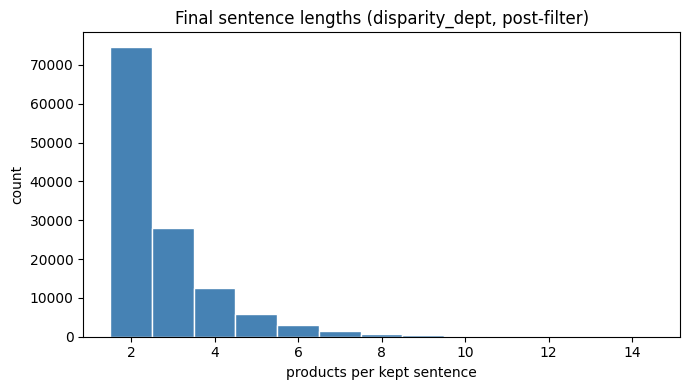

sentences kept   : 126,983
discarded (short): 273,117/400,100 (68.3%)
sentence length mean/median/max: 2.78 / 2 / 14


In [10]:
sent_lengths = [len(s["sentence"]) for s in kept_sentences]

fig, ax = plt.subplots(figsize=(7, 4))
if sent_lengths:
    ax.hist(sent_lengths, bins=range(min_sentence_length, max(sent_lengths) + 2),
            align="left", color="steelblue", edgecolor="white")
ax.set_title("Final sentence lengths (disparity_dept, post-filter)")
ax.set_xlabel("products per kept sentence"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,}/{n_total:,} "
      f"({100 * n_discarded / max(n_total, 1):.1f}%)")
if sent_lengths:
    print(f"sentence length mean/median/max: "
          f"{np.mean(sent_lengths):.2f} / {int(np.median(sent_lengths))} / {max(sent_lengths)}")

### Example walks

A handful of full walks for manual inspection: anchor, the raw path (every bridge the walk crossed), and the sentence the filter kept from it.

In [11]:
kept_filtered = [x for x in filtered if len(x["sentence"]) >= min_sentence_length]
display_rng = np.random.default_rng(0)
picks = (display_rng.choice(len(kept_filtered),
                            size=min(10, len(kept_filtered)), replace=False)
         if kept_filtered else [])

for i in picks:
    x = kept_filtered[int(i)]
    print("anchor   :", name(x["anchor_id"]))
    print("raw path :", " -> ".join(names(x["raw_path"])))
    print("sentence :", " -> ".join(names(x["sentence"])))
    print("hops     :", x["hops_taken"])
    print("-" * 90)

anchor   : Vanilla Macadamia Milk
raw path : Vanilla Macadamia Milk -> Macadamia Milk Vanilla -> Gluten Free Sea Salt & Cracked Black Pepper Rice Thin Crackers -> Honeydew Melon -> Mango Chunks -> Honey Wheat Flatbread Egg White With Spinach & Mozzarella Style Cheese Product -> Organic Bread with 21 Whole Grains -> Cherry Pomegranate Greek Yogurt -> Fat Free Blueberry Yogurt -> Organic Boneless Skinless Chicken Breast -> Freshly Shredded Parmesan Cheese -> Eggo Thick & Fluffy Original Waffles -> Cocoa Puffs Cereal -> Original Life Cereal -> Gluten Freen Original Rice Pudding -> Total 2% Lowfat Plain Greek Yogurt
sentence : Vanilla Macadamia Milk -> Macadamia Milk Vanilla
hops     : 15
------------------------------------------------------------------------------------------
anchor   : Beef Flavor Family Size Rice Blend
raw path : Beef Flavor Family Size Rice Blend -> Chicken Rice Mix -> Original Ranch Salad Dressing & Seasoning Mix -> Fresh Cut Green Beans -> Original Apple 100% Juice 

## 8. Rank novelty — does the filter surface *new* substitutes?

For each stress-test anchor, look at every product its kept sentences surfaced and find where that product sits in Step 1's own full similarity ranking for the anchor (rank 1 = Step 1's nearest neighbour). Anything inside Step 1's top-10 is flagged "not new" — the walk + filter earns its keep only when it surfaces genuine substitutes ranked *far down* that list.

In [12]:
surfaced = {pid: Counter() for pid in STRESS_TEST_IDS}
for s in kept_sentences:
    a = s["anchor_id"]
    if a in surfaced:
        for p in s["sentence"]:
            if p != a:
                surfaced[a][p] += 1

# Compute each anchor's full similarity vector + rank lookup ONCE, then reuse it
# across all of that anchor's surfaced targets (instead of re-ranking per target).
print("Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?")
print("=" * 70)
for pid, nm in STRESS_TEST_IDS.items():
    if pid not in pid_to_idx:
        print(f"\n{nm} ({pid}) — not in catalogue, skipped")
        continue
    sims = embeddings @ embeddings[pid_to_idx[pid]]        # cosine vs anchor (unit-norm)
    ranks = np.empty(len(sims), dtype=int)
    ranks[np.argsort(-sims)] = np.arange(len(sims))        # rank[idx]: 0 = anchor, 1 = #1 neighbour
    print(f"\n{nm} ({pid})")
    surfaced_here = surfaced.get(pid, Counter())
    if not surfaced_here:
        print("  (no substitutes surfaced)")
    for p, c in surfaced_here.most_common():
        idx = pid_to_idx[p]
        rank = int(ranks[idx])
        flag = "  <- inside Step 1's own top-10, not new" if rank <= 10 else ""
        print(f"  {c}x  {name(p):<45} rank={rank:>6}  sim={sims[idx]:.3f}{flag}")

Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?

Whole Milk (4210)
  8x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's own top-10, not new
  5x  Half & Half                                   rank=    57  sim=0.805
  4x  Organic Fat Free Milk                         rank=   170  sim=0.765
  4x  Organic Reduced Fat 2% Milk                   rank=   598  sim=0.710
  3x  Unsweetened Almondmilk                        rank=   454  sim=0.723
  3x  Organic Milk                                  rank=    22  sim=0.834
  3x  Unsweetened Vanilla Almond Milk               rank=   356  sim=0.735
  3x  Organic Chocolate 1% Milk with DHA Omega-3    rank=   583  sim=0.712
  3x  Salted Butter                                 rank=   637  sim=0.706
  3x  Fat Free Milk                                 rank=    29  sim=0.825
  2x  Unsweetened Almond Milk                       rank=   351  sim=0.736
  2x  Vitamin D Organic Whole Milk     

## 9. Background popularity check

How common is each surfaced product overall? A "substitute" that appears in a huge fraction of baskets may just be popular rather than genuinely related. We read the per-product basket counts straight from `product_basket_freq.json` — no basket graph to rebuild.

In [13]:
print("Background popularity check: how common is each surfaced product overall?")
print("=" * 70)

for pid, nm in STRESS_TEST_IDS.items():
    anchor_freq = product_basket_count.get(pid, 0)
    anchor_pct = 100 * anchor_freq / total_baskets if total_baskets else 0
    print(f"\n{nm} ({pid}) — anchor itself appears in "
          f"{anchor_freq:,} / {total_baskets:,} baskets ({anchor_pct:.1f}%)")
    for p, c in surfaced.get(pid, Counter()).most_common(10):
        bg_freq = product_basket_count.get(p, 0)
        bg_pct = 100 * bg_freq / total_baskets if total_baskets else 0
        print(f"  {c}x found   {name(p):<40} appears in "
              f"{bg_freq:>7,} / {total_baskets:,} baskets ({bg_pct:.1f}%)")

Background popularity check: how common is each surfaced product overall?

Whole Milk (4210) — anchor itself appears in 11,103 / 1,000,000 baskets (1.1%)
  8x found   Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
  5x found   Half & Half                              appears in  21,533 / 1,000,000 baskets (2.2%)
  4x found   Organic Fat Free Milk                    appears in   8,216 / 1,000,000 baskets (0.8%)
  4x found   Organic Reduced Fat 2% Milk              appears in  14,910 / 1,000,000 baskets (1.5%)
  3x found   Unsweetened Almondmilk                   appears in  15,486 / 1,000,000 baskets (1.5%)
  3x found   Organic Milk                             appears in   8,660 / 1,000,000 baskets (0.9%)
  3x found   Unsweetened Vanilla Almond Milk          appears in   8,141 / 1,000,000 baskets (0.8%)
  3x found   Organic Chocolate 1% Milk with DHA Omega-3 appears in   1,046 / 1,000,000 baskets (0.1%)
  3x found   Salted Butter                  

## 10. Adaptive vs fixed theta — the stress-test anchors

Each stress-test anchor's computed adaptive `theta` next to constant_theta's fixed 0.70. "stricter" means a higher bar than the baseline (fewer winners logged), "looser" a lower one. The last two columns show the anchor's degree `k` (same-department candidates now) and how many of its edges were significant (`n_significant`, or "fallback" where none were and the baseline was used).

In [14]:
print(f"Adaptive theta vs constant baseline ({CONSTANT_THETA_BASELINE}) — stress-test anchors")
print("=" * 94)
print(f"{'anchor':<30}{'adaptive':>9}{'fixed':>8}{'delta':>9}{'k':>8}{'n_signif':>10}  regime")
print("-" * 94)
for pid, nm in STRESS_TEST_IDS.items():
    t = anchor_thresholds.get(pid)
    if t is None:
        print(f"{nm:<30}{'(not walked / no threshold)':>38}")
        continue
    theta_a = t["theta"]
    delta = theta_a - CONSTANT_THETA_BASELINE
    if theta_a > CONSTANT_THETA_BASELINE:
        regime = "stricter"
    elif theta_a < CONSTANT_THETA_BASELINE:
        regime = "looser"
    else:
        regime = "equal"
    nsig = "fallback" if t["fallback"] else str(t["n_significant"])
    print(f"{nm:<30}{theta_a:>9.3f}{CONSTANT_THETA_BASELINE:>8.2f}{delta:>+9.3f}"
          f"{t['k']:>8}{nsig:>10}  {regime}")

Adaptive theta vs constant baseline (0.7) — stress-test anchors
anchor                         adaptive   fixed    delta       k  n_signif  regime
----------------------------------------------------------------------------------------------
Whole Milk                        0.700    0.70   +0.000    3448  fallback  equal
Unsweetened Almond Milk           0.700    0.70   +0.000    3448  fallback  equal
Organic Salted Butter             0.700    0.70   +0.000    3448  fallback  equal
Vegan Butter                      0.700    0.70   +0.000    3448  fallback  equal
Whole Milk Plain Yogurt           0.700    0.70   +0.000    3448  fallback  equal
Coconut Yogurt                    0.700    0.70   +0.000    3448  fallback  equal


## 11. Theta distribution across all anchors

The adaptive thresholds across every walked anchor, with the fixed 0.70 baseline marked (right of the line = stricter than the fixed method, left = looser). Alongside it, the degree `k` distribution — the number worth looking at first: if the restriction did its job, this should be a visibly lower distribution than the base run's (whose median `k` was ~49,610). A high-degree anchor needs a much larger share `p_j` for any single edge to look significant, which pushes its `theta` up, so `k` shrinking is what should relax these thresholds.

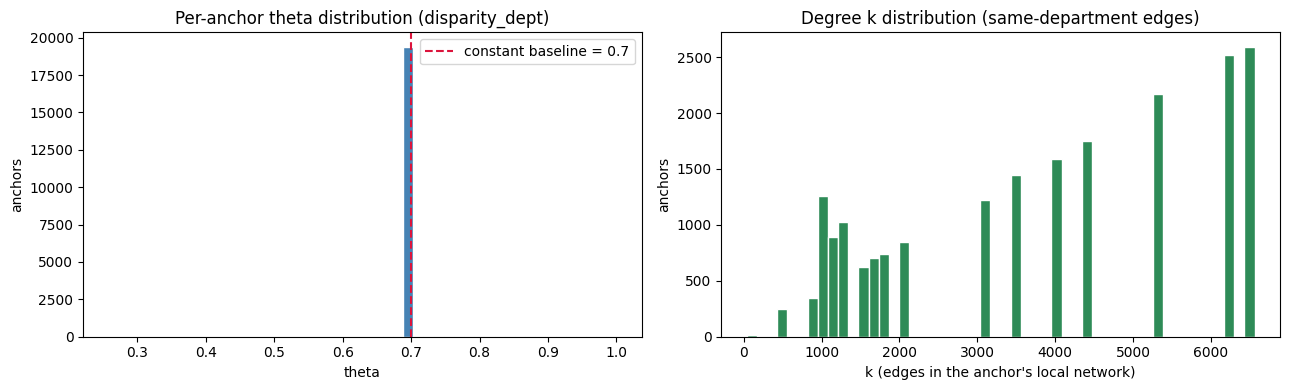

anchors with a threshold             : 20,005
stricter than 0.7 (theta > baseline)   : 514 (2.6%)
looser  than 0.7 (theta < baseline)   : 118 (0.6%)
exactly 0.7 (includes fallbacks)     : 19,373
degree k min/median/max              : 37 / 4006 / 6562


In [15]:
thetas = np.array([t["theta"] for t in anchor_thresholds.values()])
n_stricter = int((thetas > CONSTANT_THETA_BASELINE).sum())   # higher bar than the fixed baseline
n_looser = int((thetas < CONSTANT_THETA_BASELINE).sum())
n_equal = int((thetas == CONSTANT_THETA_BASELINE).sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Left: theta distribution vs the fixed baseline.
if len(thetas):
    ax[0].hist(thetas, bins=50, color="steelblue", edgecolor="white")
ax[0].axvline(CONSTANT_THETA_BASELINE, color="crimson", linestyle="--", linewidth=1.5,
              label=f"constant baseline = {CONSTANT_THETA_BASELINE}")
ax[0].set_title("Per-anchor theta distribution (disparity_dept)")
ax[0].set_xlabel("theta"); ax[0].set_ylabel("anchors")
ax[0].legend()

# Right: degree (k) distribution across all anchors — this is what explains the thetas.
ks = np.array([t["k"] for t in anchor_thresholds.values()])
if len(ks):
    ax[1].hist(ks, bins=50, color="seagreen", edgecolor="white")
ax[1].set_title("Degree k distribution (same-department edges)")
ax[1].set_xlabel("k (edges in the anchor's local network)"); ax[1].set_ylabel("anchors")

plt.tight_layout(); plt.show()

print(f"anchors with a threshold             : {len(thetas):,}")
print(f"stricter than {CONSTANT_THETA_BASELINE} (theta > baseline)   : {n_stricter:,} "
      f"({100 * n_stricter / max(len(thetas), 1):.1f}%)")
print(f"looser  than {CONSTANT_THETA_BASELINE} (theta < baseline)   : {n_looser:,} "
      f"({100 * n_looser / max(len(thetas), 1):.1f}%)")
if n_equal:
    print(f"exactly {CONSTANT_THETA_BASELINE} (includes fallbacks)     : {n_equal:,}")
if len(ks):
    print(f"degree k min/median/max              : {ks.min()} / "
          f"{int(np.median(ks))} / {ks.max()}")

---
## 12. Transform filtered walks into human-readable format

In [16]:
readable_path = FILTER_DIR / "walk_sentences_readable.txt"
prev_anchor = None
with open(readable_path, "w") as f:
    for s in kept_sentences:
        if s["anchor_id"] != prev_anchor:
            if prev_anchor is not None:
                f.write("\n")
            prev_anchor = s["anchor_id"]
        f.write(f"[{s['anchor_id']}] " + " -> ".join(names(s["sentence"])) + "\n")

print(f"Saved {readable_path.name} ({len(kept_sentences):,} lines across "
      f"{len({s['anchor_id'] for s in kept_sentences}):,} anchors)")

Saved walk_sentences__disparity_dept_readable.txt (126,983 lines across 16,085 anchors)
